In [17]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np


raw_transform = transforms.ToTensor()

trainset_raw = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=raw_transform
)

train_data = trainset_raw.data

mean = train_data.mean(axis=(0, 1, 2)) / 255.0
std = train_data.std(axis=(0, 1, 2)) / 255.0

print(f"Calculated Mean: {mean}")
print(f"Calculated Std:  {std}")

final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=final_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=final_transform
)

batch_size = 512

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print(f"\nData Pipeline Ready.")
print(f"Training Batches: {len(train_loader)}")
print(f"Testing Batches: {len(test_loader)}")

Calculated Mean: [0.49139968 0.48215841 0.44653091]
Calculated Std:  [0.24703223 0.24348513 0.26158784]

Data Pipeline Ready.
Training Batches: 98
Testing Batches: 20


## Train MLP Baseline Model

### Subtask:
Implement a training loop for the MLP model using the pre-defined `train_loader`. This involves selecting a suitable loss function (e.g., CrossEntropyLoss) and an optimizer (e.g., Adam or SGD), and iterating for a specified number of epochs.


**Reasoning**:
The user explicitly asked to implement the training loop for the MLP model, including defining the loss function, optimizer, and iterating through epochs, as per the detailed instructions.



In [10]:
import torch
import torch.nn as nn
import torchvision.models as models


class MLPBaseline(nn.Module):
    def __init__(self, input_size=3072,hidden_size=512, num_classes=10):
        super(MLPBaseline, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_size // 4, num_classes)
        )

    def forward(self, x):
        return self.model(x)

def get_vgg_model(frozen=True):

    vgg = models.vgg11(weights=models.VGG11_Weights.DEFAULT)

    if frozen:
        for param in vgg.features.parameters():
            param.requires_grad = False

    vgg.avgpool = nn.Identity()

    vgg.classifier = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 10)
    )

    return vgg


model_mlp = MLPBaseline()

model_frozen_vgg = get_vgg_model(frozen=True)

model_finetuned_vgg = get_vgg_model(frozen=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mlp.to(device)
model_frozen_vgg.to(device)
model_finetuned_vgg.to(device)

print("Models Initialized:")
print(f"1. MLP Baseline (Device: {device})")
print(f"2. Frozen VGG-11 (Features Frozen: {not next(model_frozen_vgg.features.parameters()).requires_grad})")
print(f"3. Fine-Tuned VGG-11 (Features Frozen: {not next(model_finetuned_vgg.features.parameters()).requires_grad})")

Models Initialized:
1. MLP Baseline (Device: cuda)
2. Frozen VGG-11 (Features Frozen: True)
3. Fine-Tuned VGG-11 (Features Frozen: False)


In [13]:
import torch.optim as optim
import time

def train_model(model, train_loader, val_loader, model_name, num_epochs=10, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss() #
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_loss_history = []
    train_acc_history = []
    val_acc_history = []

    print(f"--- Starting training for {model_name} ---")
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_train = 0
        correct_train = 0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs.data, 1)
            total_train+= labels.size(0)
            correct_train += (predicted == labels).sum().item()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_loss_history.append(epoch_loss)
        train_accuracy = 100 * correct_train / total_train
        train_acc_history.append(train_accuracy)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_acc = 100 * correct / total
        val_acc_history.append(epoch_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {train_accuracy:.2f} | Val Acc: {epoch_acc:.2f}%")

    total_time = time.time() - start_time
    print(f"Finished {model_name} in {total_time:.1f}s\n")

    return train_loss_history, val_acc_history

mlp_loss, mlp_acc = train_model(
    model_mlp, train_loader, test_loader, "MLP Baseline"
)



--- Starting training for MLP Baseline ---
Epoch [1/10] Train Loss: 1.4814 | Train Acc: 47.50 | Val Acc: 50.51%
Epoch [2/10] Train Loss: 1.4089 | Train Acc: 50.29 | Val Acc: 51.22%
Epoch [3/10] Train Loss: 1.3554 | Train Acc: 52.04 | Val Acc: 52.25%
Epoch [4/10] Train Loss: 1.3096 | Train Acc: 53.73 | Val Acc: 53.99%
Epoch [5/10] Train Loss: 1.2590 | Train Acc: 55.55 | Val Acc: 53.59%
Epoch [6/10] Train Loss: 1.2256 | Train Acc: 56.63 | Val Acc: 54.16%
Epoch [7/10] Train Loss: 1.1868 | Train Acc: 58.08 | Val Acc: 55.09%
Epoch [8/10] Train Loss: 1.1618 | Train Acc: 58.86 | Val Acc: 55.25%
Epoch [9/10] Train Loss: 1.1239 | Train Acc: 59.96 | Val Acc: 55.24%
Epoch [10/10] Train Loss: 1.0936 | Train Acc: 61.12 | Val Acc: 56.01%
Finished MLP Baseline in 136.7s



In [15]:
frozen_loss, frozen_acc = train_model(
    model_frozen_vgg, train_loader, test_loader, "Frozen VGG-11"
)
finetuned_loss, finetuned_acc = train_model(
    model_finetuned_vgg, train_loader, test_loader, "Fine-Tuned VGG-11", learning_rate=1e-4
)

--- Starting training for Frozen VGG-11 ---
Epoch [1/10] Train Loss: 1.1973 | Train Acc: 58.78 | Val Acc: 67.90%
Epoch [2/10] Train Loss: 0.9360 | Train Acc: 67.33 | Val Acc: 69.63%
Epoch [3/10] Train Loss: 0.8785 | Train Acc: 69.36 | Val Acc: 70.19%
Epoch [4/10] Train Loss: 0.8426 | Train Acc: 70.66 | Val Acc: 70.57%
Epoch [5/10] Train Loss: 0.8067 | Train Acc: 71.90 | Val Acc: 70.88%
Epoch [6/10] Train Loss: 0.7864 | Train Acc: 72.67 | Val Acc: 71.00%
Epoch [7/10] Train Loss: 0.7635 | Train Acc: 73.30 | Val Acc: 71.74%
Epoch [8/10] Train Loss: 0.7480 | Train Acc: 73.73 | Val Acc: 71.83%
Epoch [9/10] Train Loss: 0.7285 | Train Acc: 74.41 | Val Acc: 71.44%
Epoch [10/10] Train Loss: 0.7101 | Train Acc: 75.21 | Val Acc: 71.89%
Finished Frozen VGG-11 in 141.4s

--- Starting training for Fine-Tuned VGG-11 ---
Epoch [1/10] Train Loss: 1.1143 | Train Acc: 61.10 | Val Acc: 79.17%
Epoch [2/10] Train Loss: 0.5598 | Train Acc: 81.11 | Val Acc: 82.19%
Epoch [3/10] Train Loss: 0.4162 | Train Acc: 

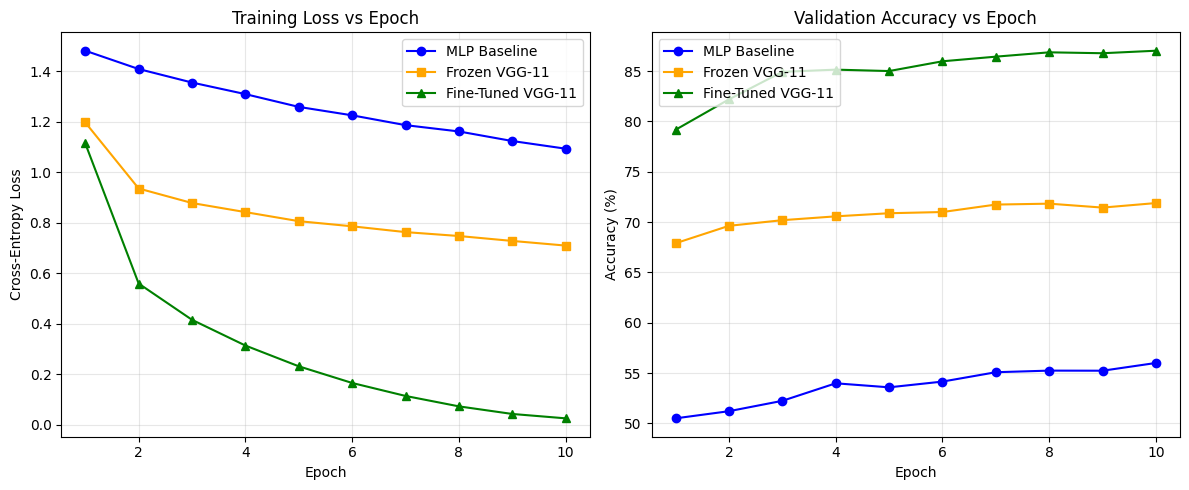

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_results(epochs,
                          mlp_loss, frozen_loss, finetuned_loss,
                          mlp_acc, frozen_acc, finetuned_acc):
    epoch_range = range(1, epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epoch_range, mlp_loss, 'o-', label='MLP Baseline', color='blue')
    plt.plot(epoch_range, frozen_loss, 's-', label='Frozen VGG-11', color='orange')
    plt.plot(epoch_range, finetuned_loss, '^-', label='Fine-Tuned VGG-11', color='green')

    plt.title('Training Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epoch_range, mlp_acc, 'o-', label='MLP Baseline', color='blue')
    plt.plot(epoch_range, frozen_acc, 's-', label='Frozen VGG-11', color='orange')
    plt.plot(epoch_range, finetuned_acc, '^-', label='Fine-Tuned VGG-11', color='green')

    plt.title('Validation Accuracy vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


try:
    plot_training_results(
        10,
        mlp_loss, frozen_loss, finetuned_loss,
        mlp_acc, frozen_acc, finetuned_acc
    )
except NameError:
    print("Error: Training history variables not found. Please run Part 3 first.")